In [1]:
import pandas as pd
import glob

import datetime as datetime
import pandas as pd
from dataIO import dataloader, webservices
from statisticscalculator import generalstatistics, climatestatistics
from plot_collection import stackedlineplots, streamflow_stat_plots, streamflow_stat_plots_matplotlib
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
from sklearn.mixture import GaussianMixture
import seaborn as sns

In [1]:
headwater_sites = {
    'So Fk Mckenzie River Abv Cougar Lake Nr Rainbow OR': [14159200, 'Willamette', 'Mckenzie River'],
    'Lookout Creek Near Blue River, OR': [14161500, 'Willamette', 'Mckenzie River'],
    'South Santiam River Below Cascadia, OR': [14185000, 'Willamette', 'South Santiam River'],
    'Quartzville Creak Near Cascadia, OR': [14185900, 'Willamette', 'South Santiam River'],
    'Blowout Creek Near Detroit, OR': [14180300, 'Willamette', 'North Santiam River'],
    'No Santiam R Blw Boulder Crk, Nr Detroit, OR': [14178000, 'Willamette', 'North Santiam River'],
    'Breitenbush R Abc French Cr Nr Detroit, OR': [14179000, 'Willamette', 'North Santiam River'],
    'South Fork Bull Run River Near Bull Run, OR': [14139800, 'Willamette', 'Bull Run'],    
    'West Fork Bitteroot River nr Conner MT': [12342500, 'Pend Oreille'],
    'Bitterroot River near Darby MT': [12344000, 'Pend Oreille'],
    'Middle Fork Rock Cr Philipsburg, MT': [12332000, 'Pend Oreille'],
    'Clark Fork ab Little Blackfoot R nr Garrison MT': [12324400, 'Pend Oreille'],
    'Little Blackfoot River near Garrison MT': [12324590, 'Pend Oreille'],
    'Swan River near Bigfork, MT': [12370000, 'Pend Oreille'],
    'Blackfoot R ab Nevada Cr nr Helmville MT': [12335100, 'Pend Oreille'],
    'S F Flathead R ab Twin C nr Hungry Horse MT': [12359800, 'Pend Oreille'],
    'St Joe River at Red Ives Ranger Station, ID': [12413875, 'Spokane'],
    'St Joe River at Ramsdell Nr St Maries ID': [12415135, 'Spokane'],
    'St Maries River Nr Santa, ID': [12414900, 'Spokane'],
    'Nf Coeur D Alene R Ab Shoshone Ck Nr Prichard ID': [12411000, 'Spokane'],
    'Nf Clearwater River Nr Canyon Ranger Station ID': [13340600, 'Clearwater'],
    'Lochsa River Nr Lowell ID': [13337000, 'Clearwater'],
    'Selway River Nr Lowell ID': [13336500, 'Clearwater'],
    'Sf Clearwater River At Stites ID': [13338500, 'Clearwater'],
    'Lemhi River Below L5 Diversion Near Salmon ID': [13305310, 'Salmon'],
    'Pahsimeroi River at Ellis ID': [13302005, 'Salmon'],
    'Salmon River Nr Shoup ID': [13307000, 'Salmon'],
    'Sf Salmon River Nr Krassel Ranger Station ID': [13310700, 'Salmon'],
    'Tobacco River at Eureka, MT': [12301250, 'Kootenay'],
    'Fisher River near Libby, MT': [12302055, 'Kootenay'],
    'Yaak River near Troy, MT': [12304500, 'Kootenay'],
    'Moyie River At Eastport ID': [12306500, 'Kootenay'],
    'Similkameen River Near Nighthawk, WA':[12442500, 'Upper Tributaries'],
    'Methow River At Winthrop, WA': [12448500, 'Upper Tributaries'],
    'Stehekin River At Stehekin, WA': [12451000, 'Upper Tributaries'],
    'Chiwawa River Near Plain, WA': [12456500, 'Upper Tributaries'],  #Wenatchee River side river
    'Wenatchee River at Plain, WA': [12457000, 'Upper Tributaries'], #Wenatchee Lake above this point.  Don't think it's regulated though.
    'Entiat River Near Entiat, WA': [12452990, 'Upper Tributaries'],
    'John Day River Near John Day, OR': [14038530, 'Lower Tributaries', 'John Day'],
    'Middle Fork John Day River At Ritter, OR': [14044000, 'Lower Tributaries', 'John Day'],
    'John Day River At Mcdonald Ferry, OR': [14048000, 'Lower Tributaries', 'John Day'],
    'Metolius River Near Grandview, OR': [14091500, 'Lower Tributaries', 'Deschutes'],
    'Shitike Crek Near Warm Springs, OR': [14093000, 'Lower Tributaries', 'Deschutes'],
    'Warm Springs River Near Kahneeta Hot Springs, OR': [14097100, 'Lower Tributaries', 'Deschutes'],
    'White River Below Tygh Valley, OR': [14101500, 'Lower Tributaries', 'Deschutes'],
    'Crooked River Blw Osborne Canyon, Nr Opal City, OR':[14087380, 'Lower Tributaries', 'Deschutes'],
    'Owyhee River Nr Rome, OR': [13181000, 'Middle Snake-Boise'],
    'Boise River Nr Twin Springs, ID':[13185000, 'Middle Snake-Boise'],
    'Sf Boise River Nr Featherville ID': [13186000, 'Middle Snake-Boise'],
    'South Fork Payette River At Lowman, ID': [13235000, 'Middle Snake-Boise'],
    'Payette River Nr Horseshoe Bend ID': [13247500, 'Middle Snake-Boise'],
    'Weiser River Nr Cambridge ID': [13258500, 'Middle Snake-Boise'],
    'Fall River Ab Yellowstone Canal Nr Squirrel ID': [13046995, 'Upper Snake'],
    'Teton River Ab South Leigh Creek Nr Driggs ID': [13052200, 'Upper Snake'],
    'Willow Creek Nr Ririe ID': [13058000, 'Upper Snake'],
    'Blackfoot River Ab Reservoir Nr Henry ID': [13063000, 'Upper Snake'],
    'Portneuf River At Topad ID': [13073000, 'Upper Snake'],
    'Big Wood R At S Broadford Brige Nr Bellevue ID': [13140335, 'Upper Snake'],
    'Salt River Above Reservoir, Near Etna, WY': [13027500, 'Snake Headwaters'],
    'Gros Ventre River At Zenith, WY': [13015000, 'Snake Headwaters'],
    'Buffalo Fork Ab Lava Creek Nr Moran WY': [13011900, 'Snake Headwaters'],
    'Hoback River Near Jackson, WY': [13019500, 'Snake Headwaters'],
}        

In [12]:
sites = []
for v in headwater_sites.values():
    sites.append(v[0])

In [11]:
headwater_sites.values()

TypeError: 'dict_values' object is not subscriptable

In [14]:
# sites

In [27]:
volume_stats_for_vip_sites = {}

# sites = 'modified_flows_m'
sites = 'headwater_sites'


#     print(site)
#     print(site[1])
if sites == 'modified_flows_m':
    for site in modified_flows_m.items():
        sitename = site[0].split('_')[0]    
        stupid = sitename.split('6')[1]
        name_of_Q_column = f'{stupid} (unit:cfs)'
        print(name_of_Q_column)
    #     data = webservices.usgs_streamflow().get_data(start_date='1921-10-01', end_date=datetime.datetime.now().strftime('%Y-%m-%d'),sites=str(site[1])).reset_index()
        d = dataloader.DataLoader(site[1], 'date', name_of_Q_column=name_of_Q_column)
        s = climatestatistics.Streamflow(d)

elif sites == 'headwater_sites':
    for site in headwater_sites.items():
        try:
            basin = site[1][1]
            data = webservices.usgs_streamflow().get_data(start_date='1921-10-01', end_date='2023-10-01',sites=str(site[1][0])).reset_index()
            d = dataloader.DataLoader(data, 'Date', name_of_Q_column='Discharge')
            s = climatestatistics.Streamflow(d)
        # except Exception as e:
        #     print(e)
        # finally:
        #     pass
        
        
    # print('-------------------------------------------------')  

            mann_kendall_results = {}
  
            s.calc_max(calc_from_rolling_median=False, window_size=7)
            print(f'Mann-Kendall Test Results looking for trend in day of year on peak runoff dates: {s.rolling_yr_Qmax_mk_test}')
            print(f'Mann-Kendall Test Results looking for trend in discharge  on peak runoff dates: {s.rolling_yr_DOYmax_mk_test}')
        #     peak_runoff_plot = streamflow_stat_plots.Plot_Peak_Runoff(s)
        #     peak_runoff_plot = peak_runoff_plot.plot_peak_runoff(site[0])
            print('-------------------------------------------------')  
        
            s.calc_annual_runoff_threshold_day(0.5, alpha=.05)
        #     volume_stats_for_vip_sites[site[1]] = s.threshold_vol_stats 
            print(f'Mann-Kendall Test Results looking for trend in {s._percent*100}% runoff timing: {s.threshold_vol_mann_kendall_test}')
            print(f'Mann-Kendall Test Results looking for trend in total annual discharge: {s.total_volume_mann_kendall_test}')  
        #     threshold_runoff_plot = streamflow_stat_plots.Plot_Runoff_Threshold(s)
        #     threshold_runoff_plot.plot_runoff_threshold(site[0])
        
        #     threshold_runoff_plot = streamflow_stat_plots_matplotlib.Plot_Runoff_Threshold(s)
        #     threshold_runoff_plot.plot_runoff_threshold(site[0])
            print('-------------------------------------------------')
            
        #     for day in ['01-01', '03-01', '05-01', '08-01']:
            s.calc_runoff_bw_days(begin_month_day='01-01', end_month_day='12-31', alpha=.05)
            print(f'Mann-Kendall Test Results looking for trend in discharge from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
        #     runoff_bw_dates_plot = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
        #     runoff_bw_dates_plot.plot_runoff_volume_between_2days(site[0])
        
            print('-------------------------------------------------')      

            s.calc_runoff_bw_days(begin_month_day='10-01', end_month_day='12-31', alpha=.05)
            print(f'Mann-Kendall Test Results looking for trend in discharge from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
            runoff_bw_dates_plot = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
            # runoff_bw_dates_plot.plot_runoff_volume_between_2days(site[0])
            mann_kendall_results['Fall Vol']=s.volume_bw_days_mann_kendall_test
            print('-------------------------------------------------')
        #     for day in ['01-01', '03-01', '05-01', '08-01']:
            s.calc_runoff_bw_days(begin_month_day='01-01', end_month_day='04-15', alpha=.05)
            print(f'Mann-Kendall Test Results looking for trend in discharge from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
            runoff_bw_dates_plot = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
            # runoff_bw_dates_plot.plot_runoff_volume_between_2days(site[0])
            mann_kendall_results['Winter Vol']=s.volume_bw_days_mann_kendall_test
            print('-------------------------------------------------')
        #     for day in ['01-01', '03-01', '05-01', '08-01']:
            s.calc_runoff_bw_days(begin_month_day='07-01', end_month_day='10-01', alpha=.05)
            print(f'Mann-Kendall Test Results looking for trend in discharge from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
        #     runoff_bw_dates_plot2 = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
        #     runoff_bw_dates_plot2.plot_runoff_volume_between_2days(site[0])
            mann_kendall_results['Vol bw days MK Test'] = s.volume_bw_days_mann_kendall_test
            print('-------------------------------------------------')            
        #     for day in ['01-01', '03-01', '05-01', '08-01']:
        #     s.calc_runoff_bw_days(begin_month_day='05-01', end_month_day='7-01', alpha=.05)
        #     print(f'Mann-Kendall Test Results looking for trend in discharge from {s.begin_month_day} to {s.end_month_day}: {s.volume_bw_days_mann_kendall_test}')
        #     runoff_bw_dates_plot3 = streamflow_stat_plots.Plot_Runoff_Volume_Between_2Days(s)
        #     runoff_bw_dates_plot3.plot_runoff_volume_between_2days(site[0])
           
            
            mann_kendall_results['Q on date of peak Q date MK Test'] = s.rolling_yr_Qmax_mk_test
            mann_kendall_results['dayofyear on date of peak Q date MK Test'] = s.rolling_yr_DOYmax_mk_test
            mann_kendall_results['Threshold Vol MK Test'] = s.threshold_vol_mann_kendall_test
            mann_kendall_results['Threshold Vol DOY MK Test'] = s.threshold_vol_dates_mann_kendall_test
            mann_kendall_results['Total Vol MK Test'] = s.total_volume_mann_kendall_test
            mann_kendall_results['Basin'] = basin
            volume_stats_for_vip_sites[site[0]] = mann_kendall_results
        except Exception as e:
            print(e)
        finally:
            pass
    print('---------------------------------------------------------------------------------------------------')    
#     historical_plot = stackedlineplots.StaticPlotter(s,
#             water_year_on=True,
#             title=site[0],
#             highlight_years=[2024],
#             plot_central_tendency_stats=True,
#             quartile_shading=False, 
# #             quartile_shading_alpha=0.00,
#             series_labels=False,
#             series_alpha=.1,
# #                     y_upper_lim=20000,
#             y_lower_lim=0,
#             legend_pos="best",
#             legend_mode="partial",
#             legend_ncol=1,)


#     with open('statplots.html', 'a') as f:
#         f.write(peak_runoff_plot.plot_peak_runoff(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))
#         f.write(threshold_runoff_plot.plot_runoff_threshold(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))
#         f.write(runoff_bw_dates_plot.plot_runoff_volume_between_2days(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))
#         f.write(runoff_bw_dates_plot2.plot_runoff_volume_between_2days(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))
#         f.write(runoff_bw_dates_plot3.plot_runoff_volume_between_2days(site[0]).to_html(full_html=False, include_plotlyjs='cdn'))   
        #         f.write(historical_plot.to_html(full_html=False, include_plotlyjs='cdn'))

https://waterservices.usgs.gov/nwis/dv/?format=json&sites=14159200&startDT=1921-10-01&endDT=2023-10-01&siteStatus=all&parameterCd=00060
Mann-Kendall Test Results looking for trend in day of year on peak runoff dates: Mann_Kendall_Test(trend='no trend', h=False, p=0.3859362521185776, z=0.8670105082120276, Tau=0.08272859216255443, s=114.0, var_s=16986.666666666668, slope=3.431372549019608, intercept=1530.7843137254902)
Mann-Kendall Test Results looking for trend in discharge  on peak runoff dates: Mann_Kendall_Test(trend='no trend', h=False, p=0.46139384918966675, z=0.7365536189851297, Tau=0.07039187227866474, s=97.0, var_s=16987.666666666668, slope=0.36602870813397126, intercept=88.48325358851675)
-------------------------------------------------
Mann-Kendall Test Results looking for trend in 50.0% runoff timing: Mann_Kendall_Test(trend='no trend', h=False, p=0.2211386811732483, z=-1.2235058892792088, Tau=-0.11530398322851153, s=-165.0, var_s=17967.0, slope=-0.17796851851851792, interce

In [28]:
sites = []
# basins = []

PeakRunoffQ_trend = []
PeakRunoffQ_h = []
PeakRunoffQ_p = []
PeakRunoffQ_tau = []

PeakRunoffDOY_trend = []
PeakRunoffDOY_h = []
PeakRunoffDOY_p = []
PeakRunoffDOY_tau = []

ThresholdVol_trend = []
ThresholdVol_h = []
ThresholdVol_p = []
ThresholdVol_tau = []

ThresholdDOY_trend = []
ThresholdDOY_p = []
ThresholdDOY_tau = []

ThresholdQ_trend = []
ThresholdQ_h = []
ThresholdQ_p = []
ThresholdQ_tau = []

TotalVol_trend = []
TotalVol_h = []
TotalVol_p = []
TotalVol_tau = []

Volbwdays_trend = []
Volbwdays_h = []
Volbwdays_p = []
Volbwdays_tau = []

WinterVol_trend = []
WinterVol_h = []
WinterVol_p = []
WinterVol_tau = []

FallVol_trend = []
FallVol_h = []
FallVol_p = []
FallVol_tau = []

for site in volume_stats_for_vip_sites.items():
    
    sites.append(site[0])
    # basins.append(site[1]['Basin'])
    
    PeakRunoffQ_trend.append(site[1]['Q on date of peak Q date MK Test'][0])
#     PeakRunoff_h.append(site[1]['Q on date of peak Q date MK Test'][2])
    PeakRunoffQ_p.append(site[1]['Q on date of peak Q date MK Test'][2])
    PeakRunoffQ_tau.append(site[1]['Q on date of peak Q date MK Test'][4])
    
    PeakRunoffDOY_trend.append(site[1]['Q on date of peak Q date MK Test'][0])
#     PeakRunoff_h.append(site[1]['Q on date of peak Q date MK Test'][2])
    PeakRunoffDOY_p.append(site[1]['Q on date of peak Q date MK Test'][2])
    PeakRunoffDOY_tau.append(site[1]['Q on date of peak Q date MK Test'][4])    
        
    ThresholdVol_trend.append(site[1]['Threshold Vol MK Test'][0])
#     Threshold_h.append(site[1]['Threshold Vol MK Test'][2])
    ThresholdVol_p.append(site[1]['Threshold Vol MK Test'][2])
    ThresholdVol_tau.append(site[1]['Threshold Vol MK Test'][4])    
        
    ThresholdDOY_trend.append(site[1]['Threshold Vol DOY MK Test'][0])
    ThresholdDOY_p.append(site[1]['Threshold Vol DOY MK Test'][2])
    ThresholdDOY_tau.append(site[1]['Threshold Vol DOY MK Test'][4])            
        
    TotalVol_trend.append(site[1]['Total Vol MK Test'][0])
#     TotalVol_h.append(site[1]['Total Vol MK Test'][2])
    TotalVol_p.append(site[1]['Total Vol MK Test'][2])
    TotalVol_tau.append(site[1]['Total Vol MK Test'][4])
    
    Volbwdays_trend.append(site[1]['Vol bw days MK Test'][0])
#     Volbwdays_h.append(site[1]['Vol bw days MK Test'][2])
    Volbwdays_p.append(site[1]['Vol bw days MK Test'][2])
    Volbwdays_tau.append(site[1]['Vol bw days MK Test'][4])
    
    WinterVol_trend.append(site[1]['Winter Vol'][0])
    WinterVol_p.append(site[1]['Winter Vol'][2])
    WinterVol_tau.append(site[1]['Winter Vol'][4])

    FallVol_trend.append(site[1]['Fall Vol'][0])
    FallVol_p.append(site[1]['Fall Vol'][2])
    FallVol_tau.append(site[1]['Fall Vol'][4])
#     PeakRunoffMKTest['trend']=site[1]['Peak Runoff MK Test'][1]
#     PeakRunoffMKTest['h']=site[1]['Peak Runoff MK Test'][2]
#     PeakRunoffMKTest['p']=site[1]['Peak Runoff MK Test'][3]
#     PeakRunoffMKTest['Tau']=site[1]['Peak Runoff MK Test'][5]

In [29]:
peak_runoffQ = pd.DataFrame({'sites':sites, 'basin': basins, 'trend': PeakRunoffQ_trend,  'p': PeakRunoffQ_p, 'tau': PeakRunoffQ_tau})
peak_runoffDOY = pd.DataFrame({'sites':sites, 'basin': basins,'trend': PeakRunoffDOY_trend,  'p': PeakRunoffDOY_p, 'tau': PeakRunoffDOY_tau})
ThresholdVol = pd.DataFrame({'sites':sites, 'basin': basins,'trend': ThresholdVol_trend, 'p': ThresholdVol_p, 'tau': ThresholdVol_tau})
ThresholdDOY = pd.DataFrame({'sites':sites, 'basin': basins,'trend': ThresholdDOY_trend, 'p': ThresholdDOY_p, 'tau': ThresholdDOY_tau})
total_vol = pd.DataFrame({'sites':sites, 'basin': basins,'trend': TotalVol_trend, 'p': TotalVol_p, 'tau': TotalVol_tau})
volbwdays = pd.DataFrame({'sites':sites, 'basin': basins,'trend': Volbwdays_trend, 'p': Volbwdays_p, 'tau': Volbwdays_tau})
WinterVol = pd.DataFrame({'sites':sites, 'basin': basins,'trend': WinterVol_trend, 'p': WinterVol_p, 'tau': WinterVol_tau})
FallVol = pd.DataFrame({'sites':sites, 'basin': basins,'trend': FallVol_trend, 'p': FallVol_p, 'tau': FallVol_tau})

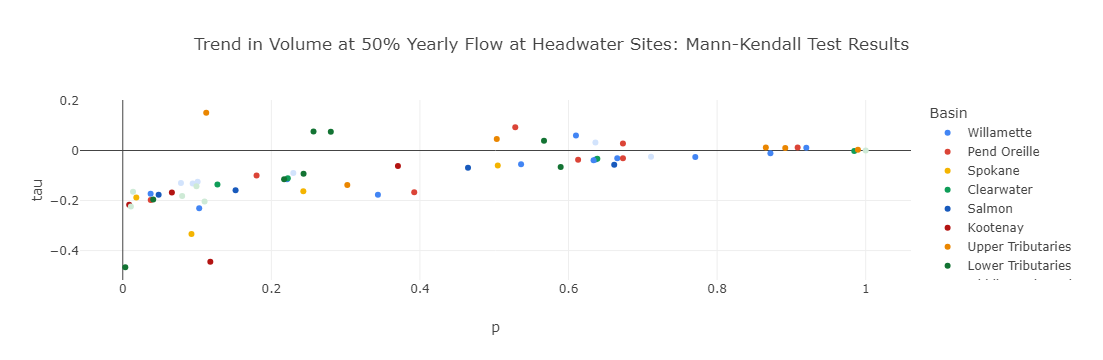

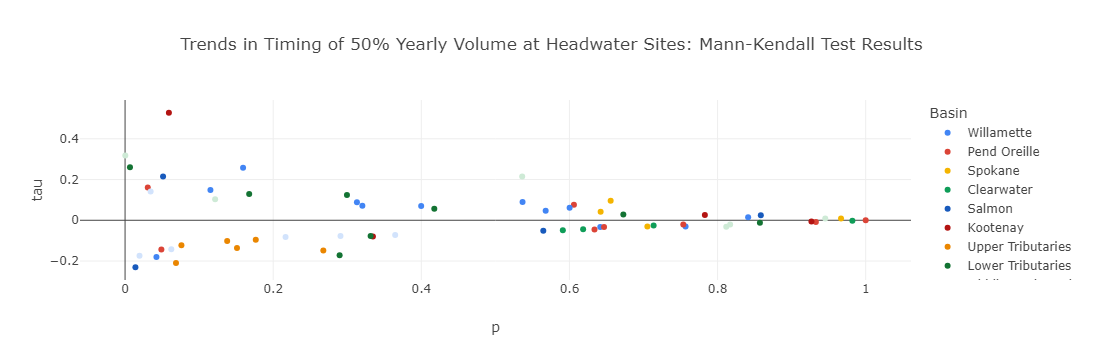

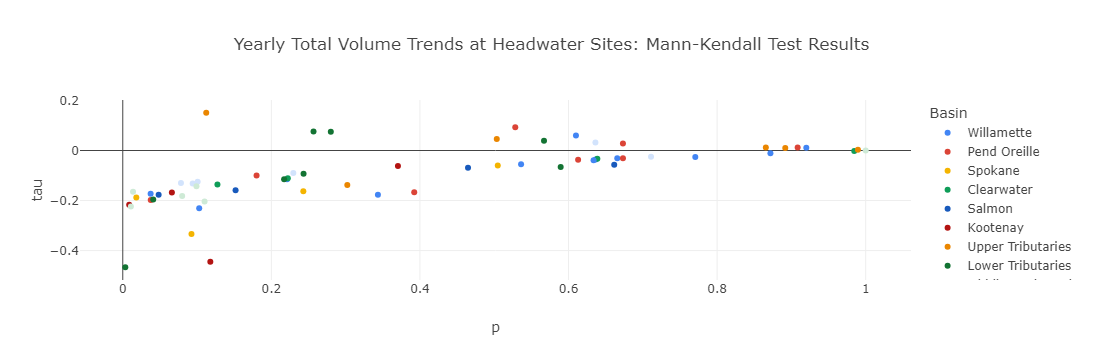

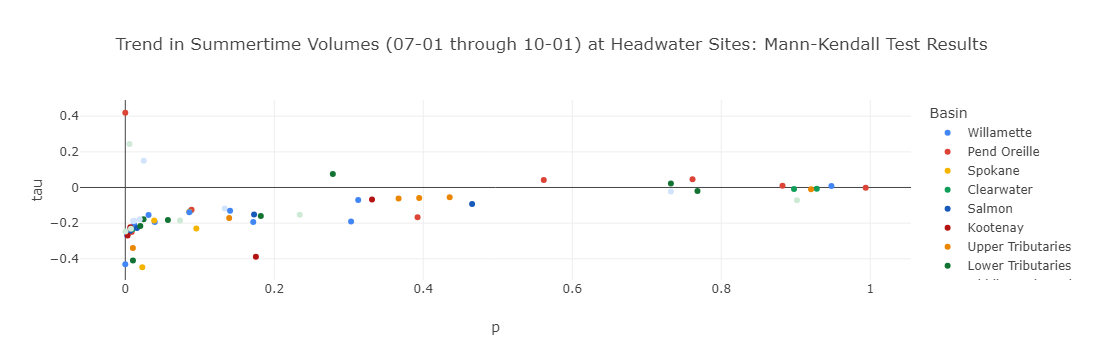

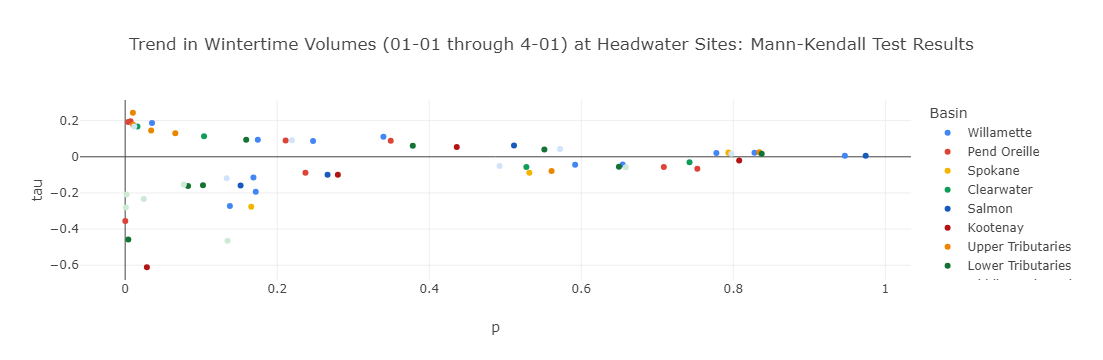

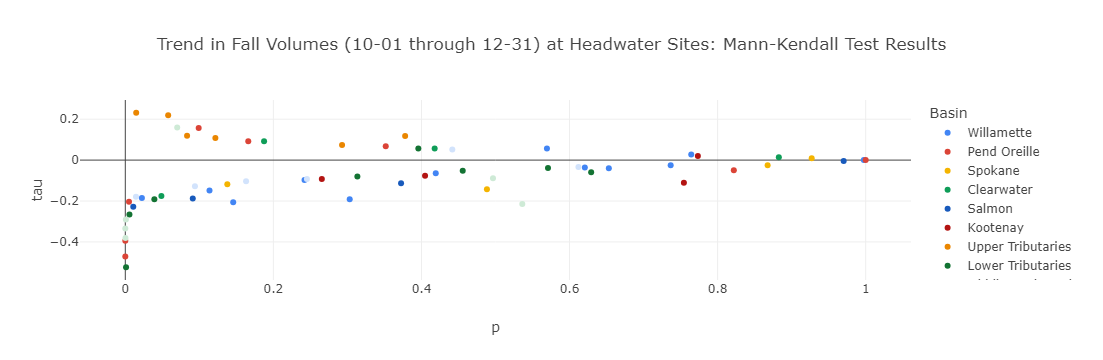

In [33]:
import plotly.express as px
import plotly.graph_objects as go

import plotly.io as pio
# pio.templates.default = 'plotly_white'
pio.templates["google"] = go.layout.Template(
    layout_colorway=['#4285F4', '#DB4437', '#F4B400', '#0F9D58',
                     '#185ABC', '#B31412', '#EA8600', '#137333',
                     '#d2e3fc', '#ceead6']
)

# setting Google color palette as default
pio.templates.default = "google"


for result in [
#     ('Qmax_mk_results', peak_runoffQ), 
#     ('PeakDOY_results', peak_runoffDOY), 
    ('ThresholdVol', ThresholdVol),
    ('ThresholdDOY', ThresholdDOY),
    ('total_vol',total_vol),
    ('volbwdays',volbwdays),
    ('WinterVol', WinterVol),
    ('FallVol', FallVol)
    ]:
    # kmeans = KMeans(n_clusters=4, init='random')
    # kmeans.fit(result[1][['p','tau']])
#     fig = px.scatter(result, 'p', 'tau', color=kmeans.labels_,
# #                      title=f'{result}',
#                      hover_data={'Cluster': kmeans.labels_, 'Site': result['sites'], 'Trend': result['trend']},
#                      labels={'color':'Cluster'})

    fig = go.Figure()
    
    
#     marker_styles = {
#     'increasing': {'color':'green', 'symbol':'triangle-up', 'size': 10},
#     'decreasing': {'color':'red', 'symbol':'triangle-down', 'size': 10},
#     'no trend': {'color':'blue', 'symbol':'circle', 'size': 5}
#     }
    
# #     for site in result[1]['sites'].unique():
# #         site_data = result[1][result[1]['sites']==site]
# #         fig.add_trace(
# #             go.Scatter(
# #                 y=site_data['tau'],
# #                 x=site_data['p'],
# #                 mode='markers',
# #                 name=site,
# #                 text = site_data
# #             )
# #         )
    
#     for trend in result[1]['trend'].unique():
#         trend_data = result[1][result[1]['trend']==trend]
#         fig.add_trace(
#             go.Scatter(
#                 y=trend_data['tau'],
#                 x=trend_data['p'],
#                 mode='markers',
#                 name=trend,
#                 marker=dict(
#                     color=marker_styles[trend]['color'],
#                     symbol=marker_styles[trend]['symbol'],
#                     size=marker_styles[trend]['size']),
#                 text = trend_data['sites'],
#                 hovertemplate='<b>Site:</b> %{text}<br><b>P-value:</b> %{x}<br><b>Tau:</b> %{y}'
                
                
#             )
#         )

    marker_styles = {
    'increasing': {'color':'green', 'symbol':'triangle-up', 'size': 10},
    'decreasing': {'color':'red', 'symbol':'triangle-down', 'size': 10},
    'no trend': {'color':'blue', 'symbol':'circle', 'size': 5}
    }
    

    
    for basin in result[1]['basin'].unique():
        basin_data = result[1][(result[1]['basin']==basin)]
        # basin_data = result[1][result[1]['basin']==basin]
        # print(basin_data)
        # print(list(basin_data['trend'])[0])
        # print(marker_styles[basin_data['trend'][0]]['symbol'])
        fig.add_trace(
            go.Scatter(
                y=basin_data['tau'],
                x=basin_data['p'],
                mode='markers',
                name=basin,
                marker=dict(
                    # symbol=basin_data['trend']
                    # color=marker_styles[trend]['color'],
                    # symbol=marker_styles[list(basin_data['trend'])[0]]['symbol'],
                    # size=marker_styles[trend]['size']
                ),
                text = basin_data['sites'],
                hovertemplate='<b>Site:</b> %{text}<br><b>P-value:</b> %{x}<br><b>Tau:</b> %{y}<br><b>Trend:</b> %{basin_data[trend][0]}'
    
            )
        )

    # for basin in result[1]['basin'].unique():
    #     for trend in result[1]['trend'].unique():
    #         basin_data = result[1][(result[1]['trend']==trend) & (result[1]['basin']==basin)]
    #         # basin_data = result[1][result[1]['basin']==basin]
    #         # print(basin_data)
    #         # print(trend)
    #         # print(list(basin_data['trend'])[0])
    #         # print(marker_styles[basin_data['trend'][0]]['symbol'])
    #         fig.add_trace(
    #             go.Scatter(
    #                 y=basin_data['tau'],
    #                 x=basin_data['p'],
    #                 mode='markers',
    #                 name=basin,
    #                 marker=dict(
    #                     # symbol=basin_data['trend']
    #                     # color=marker_styles[trend]['color'],
    #                     # symbol=marker_styles[list(basin_data['trend'])[0]]['symbol'],
    #                     # size=marker_styles[trend]['size']
    #                 ),
    #                 text = basin_data['sites'] + 'Trend: ' + basin_data['trend'],
    #                 hovertemplate=f'<b>Site:</b> %{text}<br><b>P-value:</b> %{x}<br><b>Tau:</b> %{y}<br><b>Trend:</b> %{basin_data['trend']}'
        
    #             )
    #         )
    
    # for basin in result[1]['basin'].unique():
    #     basin_data = result[1][result[1]['basin']==basin]
    #     # print(basin_data['trend'])
    #     for _, row in basin_data.iterrows():
    #         # print(_)
    #         # print(row)
    #         fig.add_trace(
    #             go.Scatter(
    #                 y=basin_data['tau'],
    #                 x=basin_data['p'],
    #                 mode='markers',
    #                 name=row['basin'],
    #                 # marker=dict(
    #                     # symbol=basin_data['trend']
    #                     # color=marker_styles[trend]['color'],
    #                     # symbol=marker_styles[trend]['symbol'],
    #                 #     size=marker_styles[trend]['size']
    #                 # ),
    #                 text = row,
    #                 hovertemplate='<b>Site:</b> %{text}<br><b>P-value:</b> %{x}<br><b>Tau:</b> %{y}'
        
    #             )
    #     )
        
    if result[0]=='Qmax_mk_results':
        title= 'Trend in Peak Discharge'
    elif result[0]=='PeakDOY_results':
        title= 'Trend in Day of Peak Discharge'
    elif result[0]=='total_vol':
        title= 'Yearly Total Volume Trends at Headwater Sites: Mann-Kendall Test Results'
    elif result[0]=='ThresholdVol':
        title = 'Trend in Volume at 50% Yearly Flow at Headwater Sites: Mann-Kendall Test Results'
    elif result[0]=='ThresholdDOY':
        title='Trends in Timing of 50% Yearly Volume at Headwater Sites: Mann-Kendall Test Results'
    elif result[0]=='volbwdays':
        title='Trend in Summertime Volumes (07-01 through 10-01) at Headwater Sites: Mann-Kendall Test Results'
    elif result[0]=='WinterVol':
        title='Trend in Wintertime Volumes (01-01 through 4-01) at Headwater Sites: Mann-Kendall Test Results'
    elif result[0]=='FallVol':
        title='Trend in Fall Volumes (10-01 through 12-31) at Headwater Sites: Mann-Kendall Test Results'
       
    fig.update_layout(
        title=title,
        xaxis_title = 'p',
        yaxis_title = 'tau',
        legend_title = 'Basin',
        legend = dict(
            itemclick='toggle',
            itemdoubleclick = 'toggleothers'),
        # autosize=False,
        # width=1200,
        # height=400,
    )
    fig.show()
    
    with open('HeadwaterSites_MK_Results.html', 'a') as f:
        f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

In [31]:
# ThresholdDOY

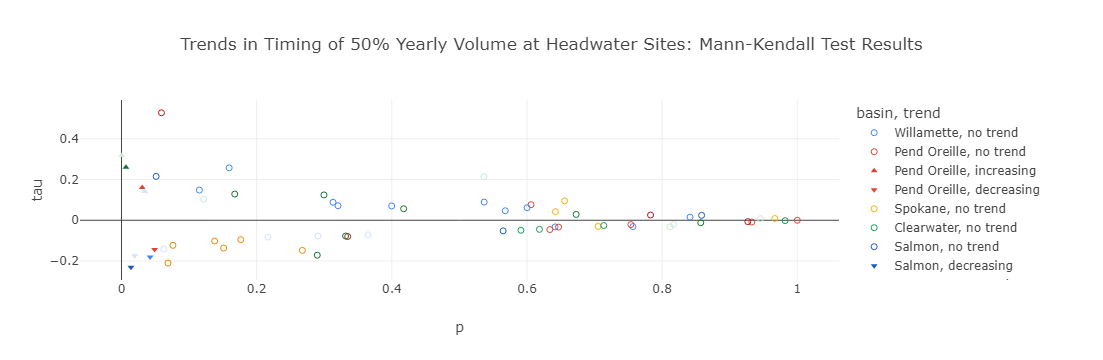

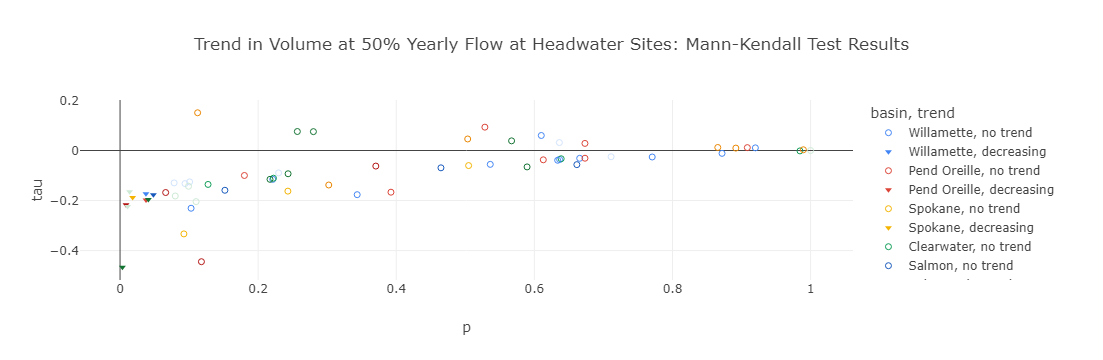

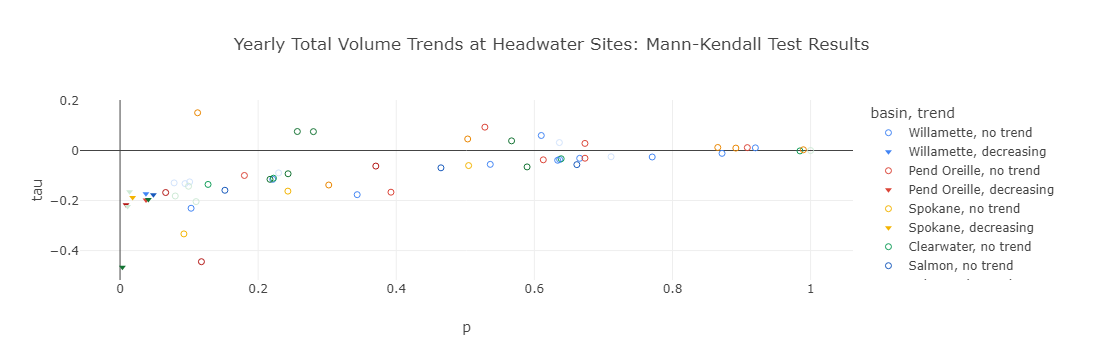

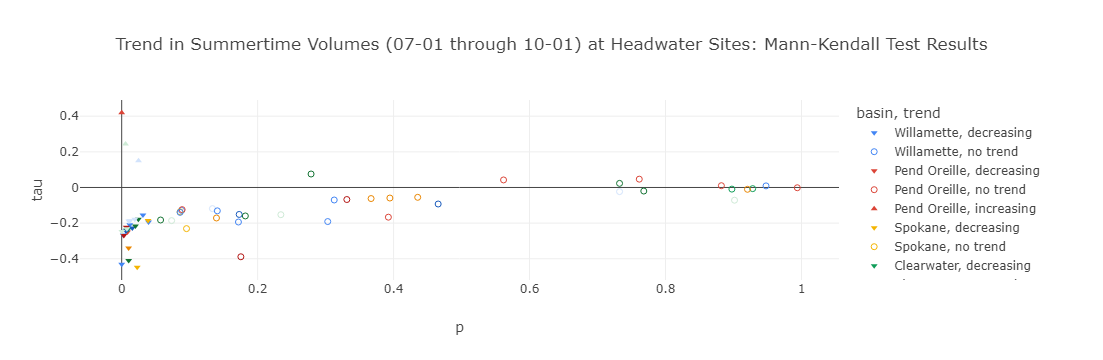

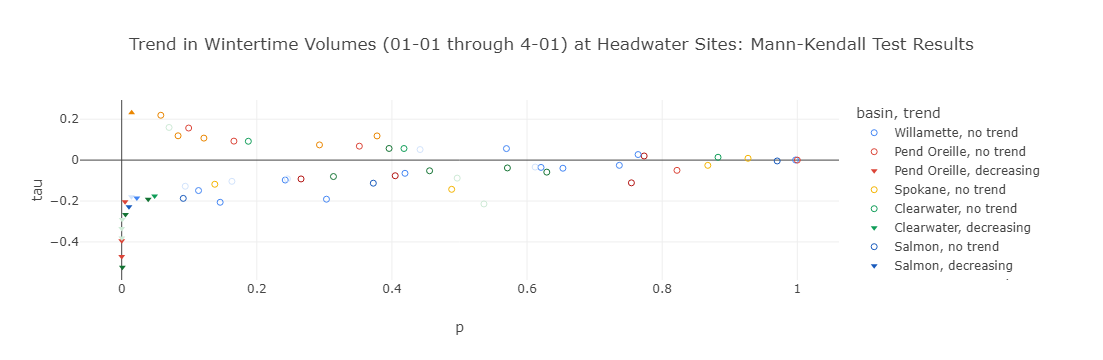

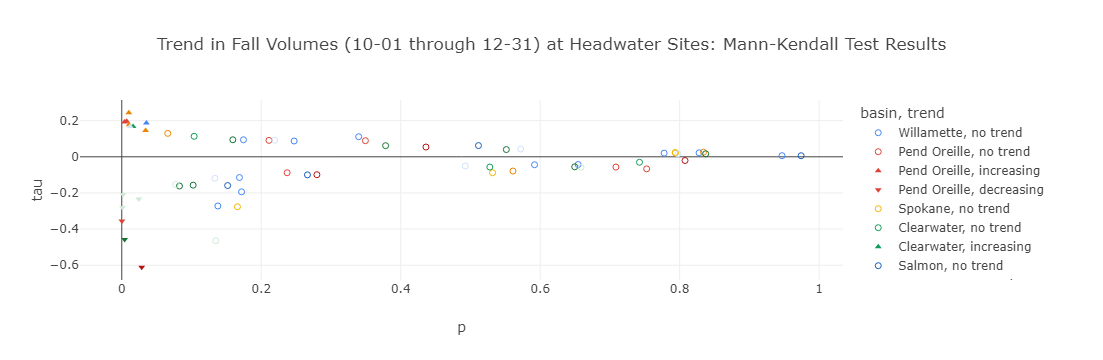

In [34]:
import plotly.express as px
fig = px.scatter(ThresholdDOY, 'p', 'tau', color='basin',
                 title='Trends in Timing of 50% Yearly Volume at Headwater Sites: Mann-Kendall Test Results',
                 hover_data={'Basin': ThresholdDOY['basin'], 'Site': ThresholdDOY['sites'], 'Trend': ThresholdDOY['trend'],},
                 symbol = ThresholdDOY['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'},
                 # text='sites',
                 # size_max=8
                 # labels={'color':'Cluster'}
                )
# fig.update_layout(textfont_size=5)
fig.show()
with open('HeadwaterSites_MK_Results2.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))
fig = px.scatter(ThresholdVol, 'p', 'tau', color='basin',
                 title='Trend in Volume at 50% Yearly Flow at Headwater Sites: Mann-Kendall Test Results',
                 hover_data={'Basin': ThresholdVol['basin'], 'Site': ThresholdVol['sites'], 'Trend': ThresholdVol['trend'],},
                 symbol = ThresholdVol['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('HeadwaterSites_MK_Results2.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

fig = px.scatter(total_vol, 'p', 'tau', color='basin',
                 title='Yearly Total Volume Trends at Headwater Sites: Mann-Kendall Test Results',
                 hover_data={'Basin': total_vol['basin'], 'Site': total_vol['sites'], 'Trend': total_vol['trend'],},
                 symbol = total_vol['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('HeadwaterSites_MK_Results2.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

fig = px.scatter(volbwdays, 'p', 'tau', color='basin',
                 title='Trend in Summertime Volumes (07-01 through 10-01) at Headwater Sites: Mann-Kendall Test Results',
                 hover_data={'Basin': volbwdays['basin'], 'Site': volbwdays['sites'], 'Trend': volbwdays['trend'],},
                 symbol = volbwdays['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('HeadwaterSites_MK_Results2.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))

fig = px.scatter(FallVol, 'p', 'tau', color='basin',
                 title='Trend in Wintertime Volumes (01-01 through 4-01) at Headwater Sites: Mann-Kendall Test Results',
                 hover_data={'Basin': FallVol['basin'], 'Site': FallVol['sites'], 'Trend': FallVol['trend'],},
                 symbol = FallVol['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('HeadwaterSites_MK_Results2.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))
fig = px.scatter(WinterVol, 'p', 'tau', color='basin',
                 title='Trend in Fall Volumes (10-01 through 12-31) at Headwater Sites: Mann-Kendall Test Results',
                 hover_data={'Basin': WinterVol['basin'], 'Site': WinterVol['sites'], 'Trend': WinterVol['trend'],},
                 symbol = WinterVol['trend'],
                 symbol_map={'no trend':'circle-open', 'decreasing': 'triangle-down', 'increasing':'triangle-up'}
                 # labels={'color':'Cluster'}
                )
fig.show()
with open('HeadwaterSites_MK_Results2.html', 'a') as f:
    f.write(fig.to_html(full_html=False, include_plotlyjs='cdn', default_width=1200, default_height=400))